# Import modules and libraries

In [4]:
# See https://simba-bio.readthedocs.io/en/latest/multiome_shareseq.html

In [5]:
import os
import simba as si
si.__version__

/home/manuel.tardaguila/.local/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/manuel.tardaguila/.local/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/manuel.tardaguila/.local/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/manuel.tardaguila/.local/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/manuel.tardaguila/.local/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `

'1.2'

In [6]:
workdir = 'result_SIMBA'
si.settings.set_workdir(workdir)

Saving results in: result_SIMBA


In [7]:
si.settings.set_figure_params(dpi=80,
                              style='white',
                              fig_size=[5,5],
                              rc={'image.cmap': 'viridis'})

In [8]:
# to make plots prettier
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

/localscratch/19736167.manuel.tardaguila/ipykernel_2041368/3381039072.py:3: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


In [9]:
import scanpy as sc

In [10]:
import re

# Load the datasets

In [11]:
RNA_adata = sc.read('/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/Downstream_analysis_cluster_after_genotyping/RNA.h5ad')

/home/manuel.tardaguila/.local/lib/python3.11/site-packages/anndata/__init__.py:52: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [12]:
RNA_adata.obs['clone_line']

MCO_01326_AAACAGCCACAGCCAT-1        DNMT3A_3
MCO_01326_AAACAGCCAGGAAGCC-1    rs62237617_1
MCO_01326_AAACAGCCAGTATGTT-1        DNMT3A_1
MCO_01326_AAACATGCAAACGCGA-1        DNMT3A_1
MCO_01326_AAACATGCAACCCTAA-1        DNMT3A_1
                                    ...     
MCO_01329_TTTGTGTTCCCGAACA-1    rs62237617_3
MCO_01329_TTTGTGTTCCGCTAGA-1        DNMT3A_1
MCO_01329_TTTGTTGGTCATGAGC-1        DNMT3A_1
MCO_01329_TTTGTTGGTGATTTGG-1        DNMT3A_1
MCO_01329_TTTGTTGGTTGTAACG-1    rs62237617_3
Name: clone_line, Length: 16835, dtype: object

In [13]:
RNA_adata

AnnData object with n_obs × n_vars = 16835 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_RNA_raw', 'nFeature_RNA_raw', 'nCount_ATAC', 'nFeature_ATAC', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'TSS.enrichment', 'TSS.percentile', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'scDblFinder.class_atac', 'scDblFi

In [14]:
ATAC_adata = sc.read('/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/Downstream_analysis_cluster_after_genotyping/ATAC.h5ad')

/home/manuel.tardaguila/.local/lib/python3.11/site-packages/anndata/__init__.py:52: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [15]:
ATAC_adata

AnnData object with n_obs × n_vars = 16835 × 306646
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_RNA_raw', 'nFeature_RNA_raw', 'nCount_ATAC', 'nFeature_ATAC', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'TSS.enrichment', 'TSS.percentile', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'scDblFinder.class_atac', 'scDblF

## Load them to the SIMBA

In [16]:
adata_CP = ATAC_adata
adata_CG = RNA_adata

In [17]:
adata_CP.obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_RNA_raw,nFeature_RNA_raw,nCount_ATAC,nFeature_ATAC,gex_raw_reads,gex_mapped_reads,...,Genotype,nCount_ATAC_by_refined_annotation,nFeature_ATAC_by_refined_annotation,Subclusters_8,Subclusters_6,rpca_annot,rpca_annot_majority_vote,nCount_ATAC_by_rpca_refined_annotation,nFeature_ATAC_by_rpca_refined_annotation,cell_type
MCO_01326_AAACAGCCACAGCCAT-1,MCO_01326,10351.0,4753,0.473384,11643.0,4772,4288.0,4089,23298,22654,...,DNMT3A,4180.0,3988,0,0,4,0,4184.0,3993,hESC
MCO_01326_AAACAGCCAGGAAGCC-1,MCO_01326,9684.0,4688,0.433705,11274.0,4715,8222.0,7465,21620,20952,...,rs62237617,7984.0,7258,0,0,4,0,7987.0,7259,hESC
MCO_01326_AAACAGCCAGTATGTT-1,MCO_01326,8467.0,4336,0.590528,9855.0,4383,9551.0,8533,19452,18917,...,DNMT3A,9316.0,8339,0,0,4,0,9315.0,8338,hESC
MCO_01326_AAACATGCAAACGCGA-1,MCO_01326,22503.0,7031,1.439808,23265.0,7032,19592.0,16539,46234,44973,...,DNMT3A,19003.0,16104,0,0,4,0,19003.0,16103,hESC
MCO_01326_AAACATGCAACCCTAA-1,MCO_01326,17298.0,6042,1.780553,18216.0,6050,15565.0,13551,37825,36744,...,DNMT3A,15349.0,13433,0,0,4,0,15339.0,13417,hESC


In [18]:
adata_CG.obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_RNA_raw,nFeature_RNA_raw,nCount_ATAC,nFeature_ATAC,gex_raw_reads,gex_mapped_reads,...,Genotype,nCount_ATAC_by_refined_annotation,nFeature_ATAC_by_refined_annotation,Subclusters_8,Subclusters_6,rpca_annot,rpca_annot_majority_vote,nCount_ATAC_by_rpca_refined_annotation,nFeature_ATAC_by_rpca_refined_annotation,cell_type
MCO_01326_AAACAGCCACAGCCAT-1,MCO_01326,10351.0,4753,0.473384,11643.0,4772,4288.0,4089,23298,22654,...,DNMT3A,4180.0,3988,0,0,4,0,4184.0,3993,hESC
MCO_01326_AAACAGCCAGGAAGCC-1,MCO_01326,9684.0,4688,0.433705,11274.0,4715,8222.0,7465,21620,20952,...,rs62237617,7984.0,7258,0,0,4,0,7987.0,7259,hESC
MCO_01326_AAACAGCCAGTATGTT-1,MCO_01326,8467.0,4336,0.590528,9855.0,4383,9551.0,8533,19452,18917,...,DNMT3A,9316.0,8339,0,0,4,0,9315.0,8338,hESC
MCO_01326_AAACATGCAAACGCGA-1,MCO_01326,22503.0,7031,1.439808,23265.0,7032,19592.0,16539,46234,44973,...,DNMT3A,19003.0,16104,0,0,4,0,19003.0,16103,hESC
MCO_01326_AAACATGCAACCCTAA-1,MCO_01326,17298.0,6042,1.780553,18216.0,6050,15565.0,13551,37825,36744,...,DNMT3A,15349.0,13433,0,0,4,0,15339.0,13417,hESC


# ATAC-seq part

## Preprocessing

In [19]:
si.pp.filter_peaks(adata_CP,min_n_cells=3)

Before filtering: 
16835 cells, 306646 peaks
Filter peaks based on min_n_cells
After filtering out low-expressed peaks: 
16835 cells, 306645 peaks


In [20]:
si.pp.cal_qc_atac(adata_CP)

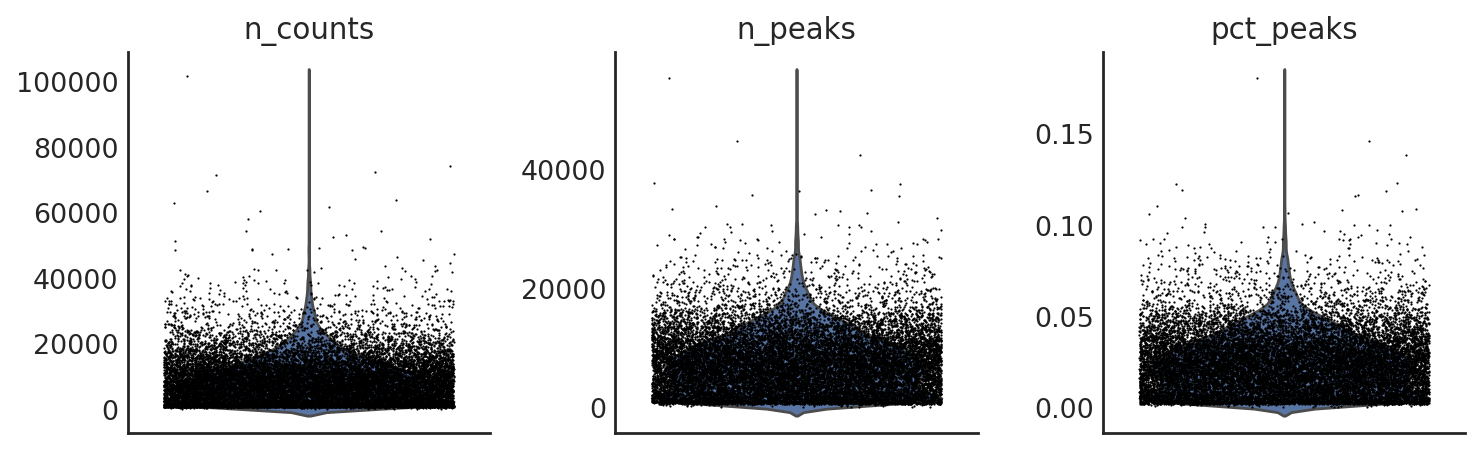

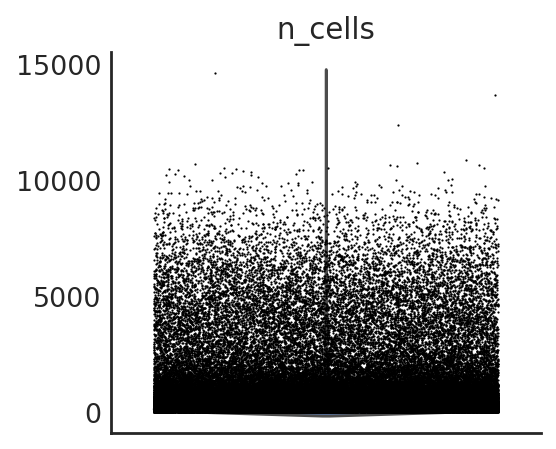

In [21]:
si.pl.violin(adata_CP,list_obs=['n_counts','n_peaks','pct_peaks'], list_var=['n_cells'])

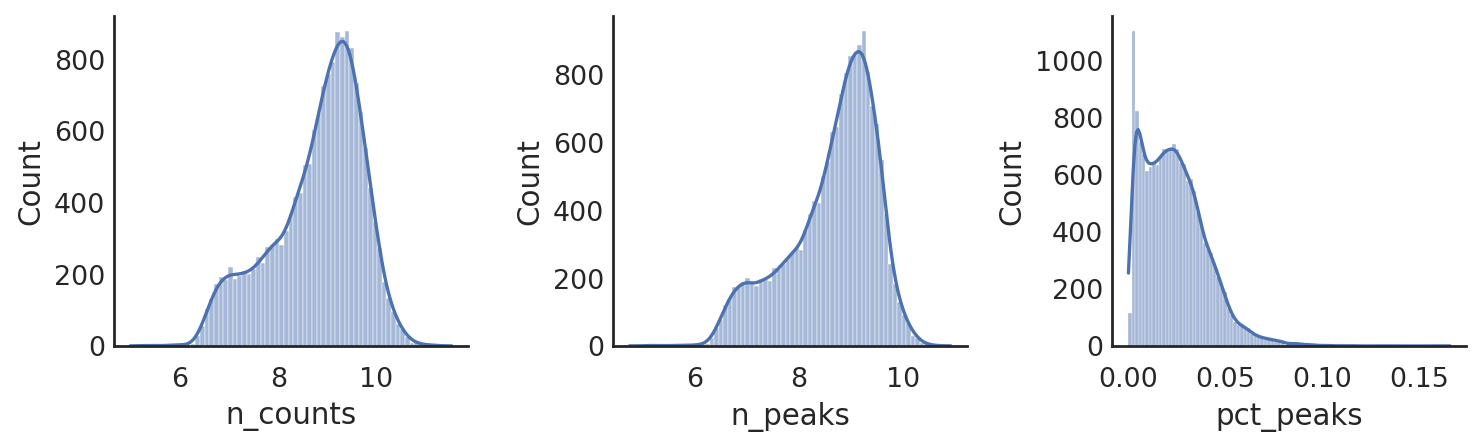

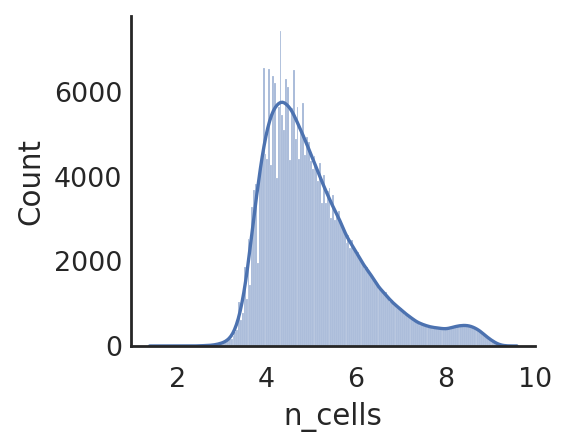

In [22]:
si.pl.hist(adata_CP,list_obs=['n_counts','n_peaks','pct_peaks'], log=True, list_var=['n_cells'])

## After having run bash ~/Scripts/Wraper_scripts/168_Simba_scan_for_kmers_motifs.sh /group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/ Downstream_analysis_cluster_after_genotyping


In [23]:
adata_PK = si.read_hdf('/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/Downstream_analysis_cluster_after_genotyping/result_SIMBA/freq_kmer.h5','mat')
adata_PM = si.read_hdf('/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/Downstream_analysis_cluster_after_genotyping/result_SIMBA//freq_motif.h5','mat')


## convert byte string to string

In [24]:

adata_PK.obs.index = [x.decode('utf-8') for x in adata_PK.obs.index]
adata_PK.var.index = [x.decode('utf-8') for x in adata_PK.var.index]

adata_PM.obs.index = [x.decode('utf-8') for x in adata_PM.obs.index]
adata_PM.var.index = [x.decode('utf-8') for x in adata_PM.var.index]

In [25]:
adata_PK


AnnData object with n_obs × n_vars = 306646 × 4096

In [26]:
adata_PM

AnnData object with n_obs × n_vars = 306646 × 633

In [27]:
si.pp.binarize(adata_PK)
si.pp.binarize(adata_PM)

## select kmers and motifs (optional)

In [28]:
si.pp.pca(adata_PK, n_components=30)
si.pp.pca(adata_PM, n_components=30)
si.pp.select_pcs_features(adata_PK, min_elbow=adata_PK.shape[1]/5, S=5)
si.pp.select_pcs_features(adata_PM, min_elbow=adata_PM.shape[1]/5, S=5)

#features selected from PC 0: 826
#features selected from PC 1: 1515
#features selected from PC 2: 1566
#features selected from PC 3: 1824
#features selected from PC 4: 1883
#features selected from PC 5: 2027
#features selected from PC 6: 2059
#features selected from PC 7: 1047
#features selected from PC 8: 1391
#features selected from PC 9: 1553
#features selected from PC 10: 1885
#features selected from PC 11: 1821
#features selected from PC 12: 1927
#features selected from PC 13: 819
#features selected from PC 14: 1291
#features selected from PC 15: 1687
#features selected from PC 16: 1840
#features selected from PC 17: 2002
#features selected from PC 18: 1852
#features selected from PC 19: 1687
#features selected from PC 20: 819
#features selected from PC 21: 1861
#features selected from PC 22: 1680
#features selected from PC 23: 2110
#features selected from PC 24: 1666
#features selected from PC 25: 1672
#features selected from PC 26: 1850
#features selected from PC 27: 1360
#feat

# RNA-seq part

## preprocessing

In [29]:
si.pp.filter_genes(adata_CG,min_n_cells=3)

Before filtering: 
16835 cells, 36601 genes
Filter genes based on min_n_cells
After filtering out low-expressed genes: 
16835 cells, 30538 genes


In [30]:
si.pp.cal_qc_rna(adata_CG)

In [31]:
si.pp.normalize(adata_CG,method='lib_size')

In [32]:
si.pp.log_transform(adata_CG)

### Optionally, variable gene selection step can be also performed.

## discretize RNA expression

In [33]:
si.tl.discretize(adata_CG,n_bins=5)


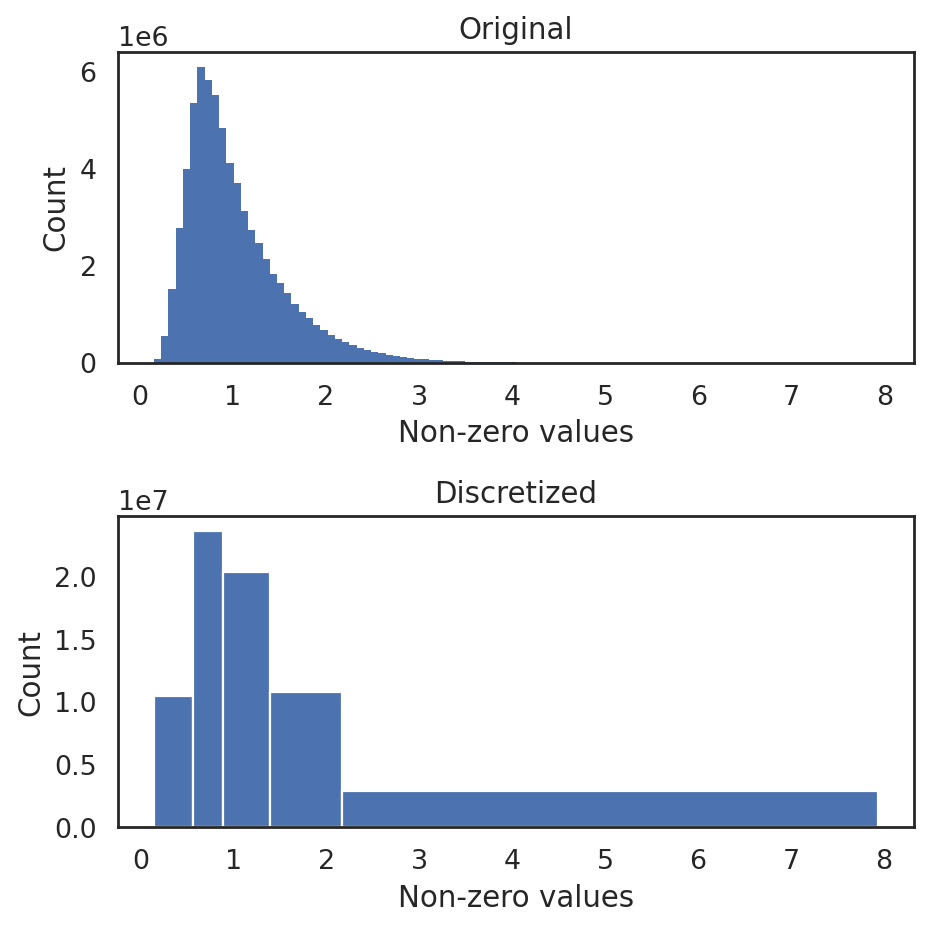

In [34]:
si.pl.discretize(adata_CG,kde=False)


# Load graph and model

In [35]:
# load in graph ('graph0') info
si.load_graph_stats(path='/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/Downstream_analysis_cluster_after_genotyping/result_SIMBA/pbg/graph0/')
# load in model info for ('graph0')
si.load_pbg_config(path='/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/Downstream_analysis_cluster_after_genotyping/result_SIMBA/pbg/graph0/model/')

## Plot to know how  the training happened

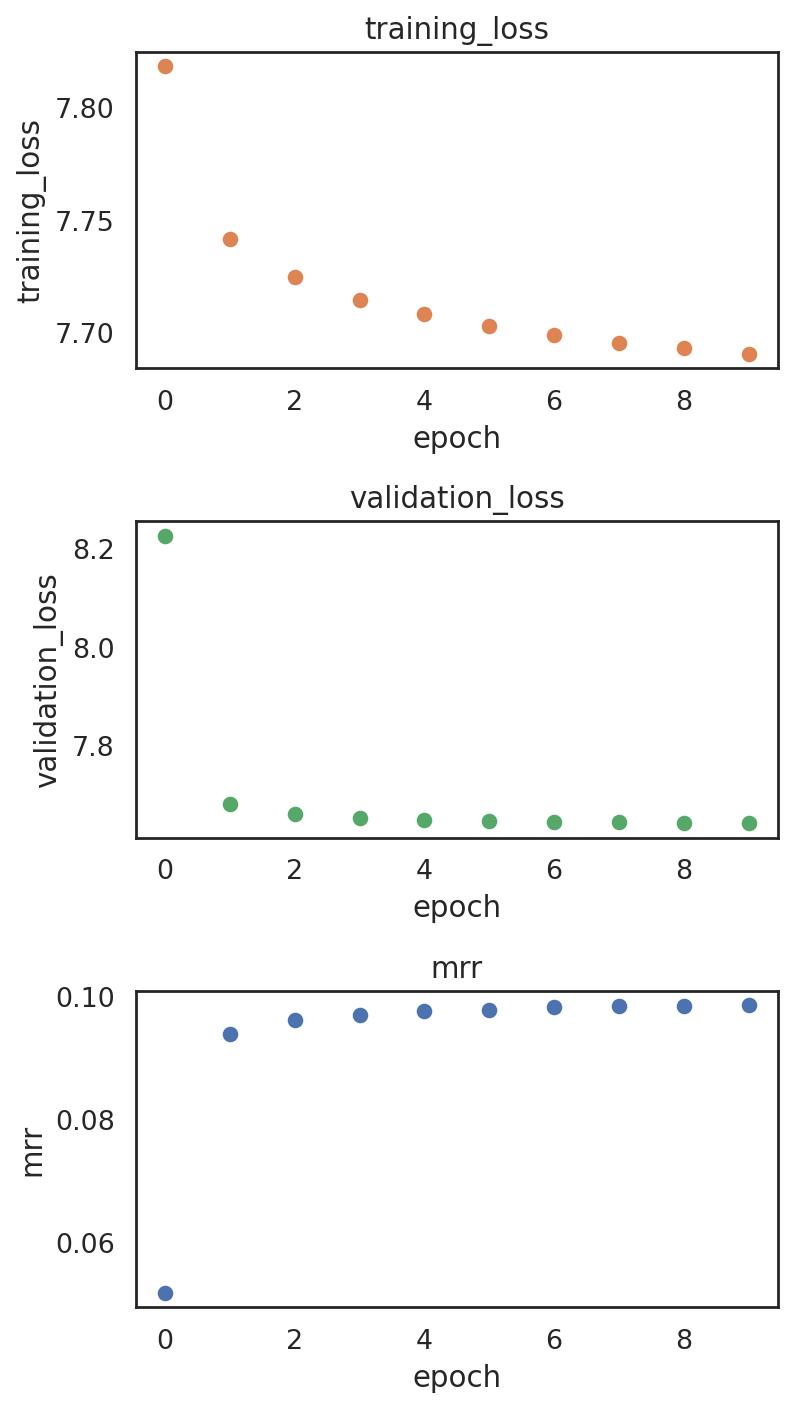

In [36]:
si.pl.pbg_metrics(fig_ncol=1)

# post-training analysis

In [37]:
dict_adata = si.read_embedding()

In [38]:
dict_adata

{'P': AnnData object with n_obs × n_vars = 613291 × 50,
 'G': AnnData object with n_obs × n_vars = 30538 × 50,
 'M': AnnData object with n_obs × n_vars = 633 × 50,
 'C': AnnData object with n_obs × n_vars = 16835 × 50,
 'K': AnnData object with n_obs × n_vars = 4096 × 50}

In [39]:
adata_C = dict_adata['C']  # embeddings for cells
adata_G = dict_adata['G']  # embeddings for genes
adata_P = dict_adata['P']  # embeddings for peaks
adata_K = dict_adata['K']  # embeddings for kmers
adata_M = dict_adata['M']  # embeddings for motifs

#### to distinguish TF motif names from gene names in this case
adata_M.obs.index = 'M_'+adata_M.obs.index

## Add annotations to cells

In [40]:
adata_CG.obs['clone_line']

MCO_01326_AAACAGCCACAGCCAT-1        DNMT3A_3
MCO_01326_AAACAGCCAGGAAGCC-1    rs62237617_1
MCO_01326_AAACAGCCAGTATGTT-1        DNMT3A_1
MCO_01326_AAACATGCAAACGCGA-1        DNMT3A_1
MCO_01326_AAACATGCAACCCTAA-1        DNMT3A_1
                                    ...     
MCO_01329_TTTGTGTTCCCGAACA-1    rs62237617_3
MCO_01329_TTTGTGTTCCGCTAGA-1        DNMT3A_1
MCO_01329_TTTGTTGGTCATGAGC-1        DNMT3A_1
MCO_01329_TTTGTTGGTGATTTGG-1        DNMT3A_1
MCO_01329_TTTGTTGGTTGTAACG-1    rs62237617_3
Name: clone_line, Length: 16835, dtype: object

In [41]:
adata_CG.obs['Genotype']

MCO_01326_AAACAGCCACAGCCAT-1        DNMT3A
MCO_01326_AAACAGCCAGGAAGCC-1    rs62237617
MCO_01326_AAACAGCCAGTATGTT-1        DNMT3A
MCO_01326_AAACATGCAAACGCGA-1        DNMT3A
MCO_01326_AAACATGCAACCCTAA-1        DNMT3A
                                   ...    
MCO_01329_TTTGTGTTCCCGAACA-1    rs62237617
MCO_01329_TTTGTGTTCCGCTAGA-1        DNMT3A
MCO_01329_TTTGTTGGTCATGAGC-1        DNMT3A
MCO_01329_TTTGTTGGTGATTTGG-1        DNMT3A
MCO_01329_TTTGTTGGTTGTAACG-1    rs62237617
Name: Genotype, Length: 16835, dtype: object

In [42]:
adata_CG.obs['refined_annotation_majority_vote']

MCO_01326_AAACAGCCACAGCCAT-1          hESC
MCO_01326_AAACAGCCAGGAAGCC-1          hESC
MCO_01326_AAACAGCCAGTATGTT-1          hESC
MCO_01326_AAACATGCAAACGCGA-1          hESC
MCO_01326_AAACATGCAACCCTAA-1          hESC
                                   ...    
MCO_01329_TTTGTGTTCCCGAACA-1            MK
MCO_01329_TTTGTGTTCCGCTAGA-1           MEP
MCO_01329_TTTGTTGGTCATGAGC-1            MK
MCO_01329_TTTGTTGGTGATTTGG-1    PolyPlo MK
MCO_01329_TTTGTTGGTTGTAACG-1    PolyPlo MK
Name: refined_annotation_majority_vote, Length: 16835, dtype: object

In [43]:
## Add annotation of celltypes (optional)
adata_C.obs['celltype'] = adata_CG[adata_C.obs_names,:].obs['refined_annotation_majority_vote'].copy()
adata_C.obs['clone_line'] = adata_CG[adata_C.obs_names,:].obs['clone_line'].copy()
adata_C.obs['Genotype'] = adata_CG[adata_C.obs_names,:].obs['Genotype'].copy()

adata_C

AnnData object with n_obs × n_vars = 16835 × 50
    obs: 'celltype', 'clone_line', 'Genotype'

## Visualize cell types

In [44]:
si.tl.umap(adata_C,n_neighbors=15,n_components=2)


/group/soranzo/conda_envs/env_simba/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/group/soranzo/conda_envs/env_simba/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


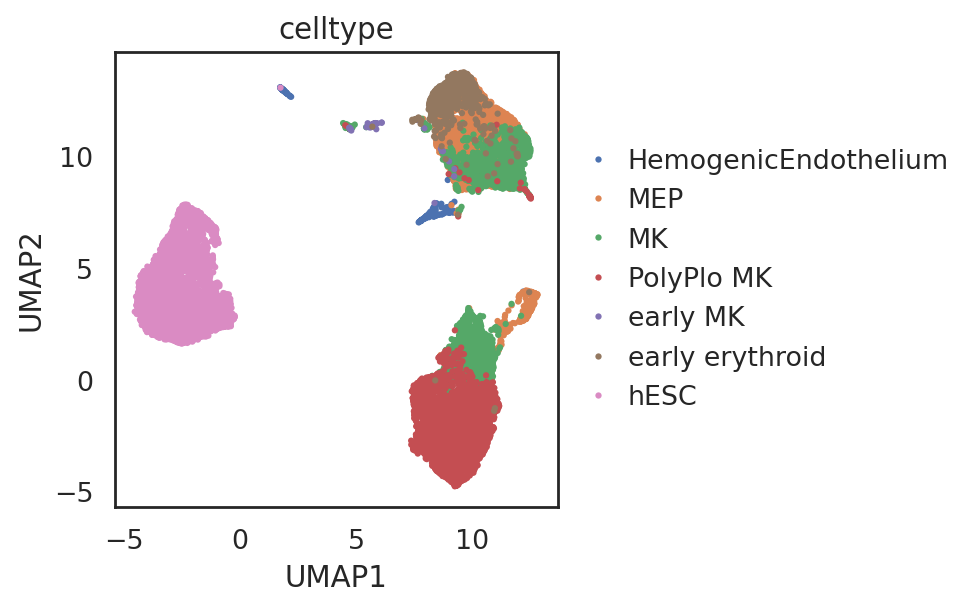

In [45]:
si.pl.umap(adata_C,
           color=['celltype'],
           fig_size=(6,4),
           drawing_order='sorted')

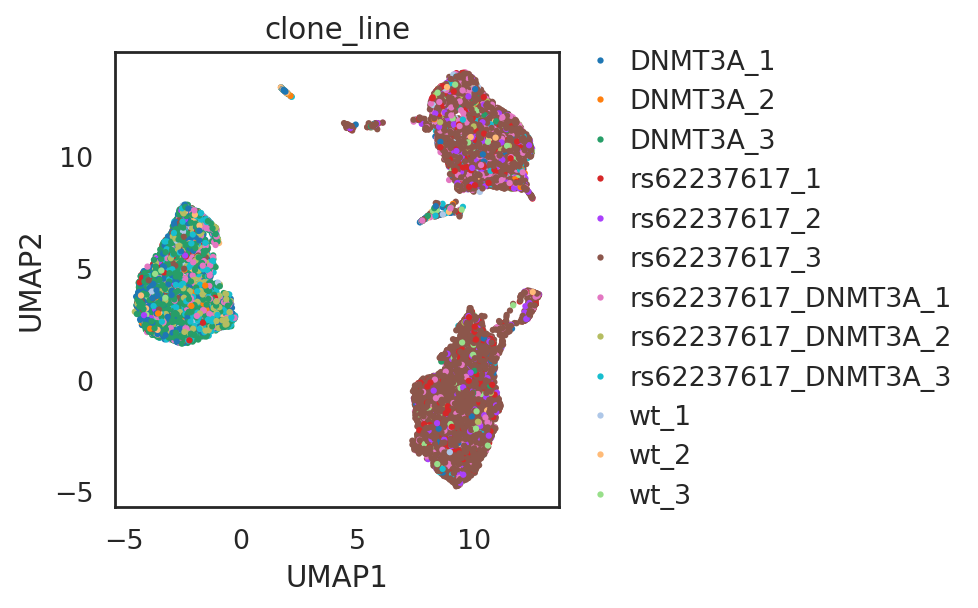

In [46]:
si.pl.umap(adata_C,
           color=['clone_line'],
           fig_size=(6,4),
           drawing_order='random')

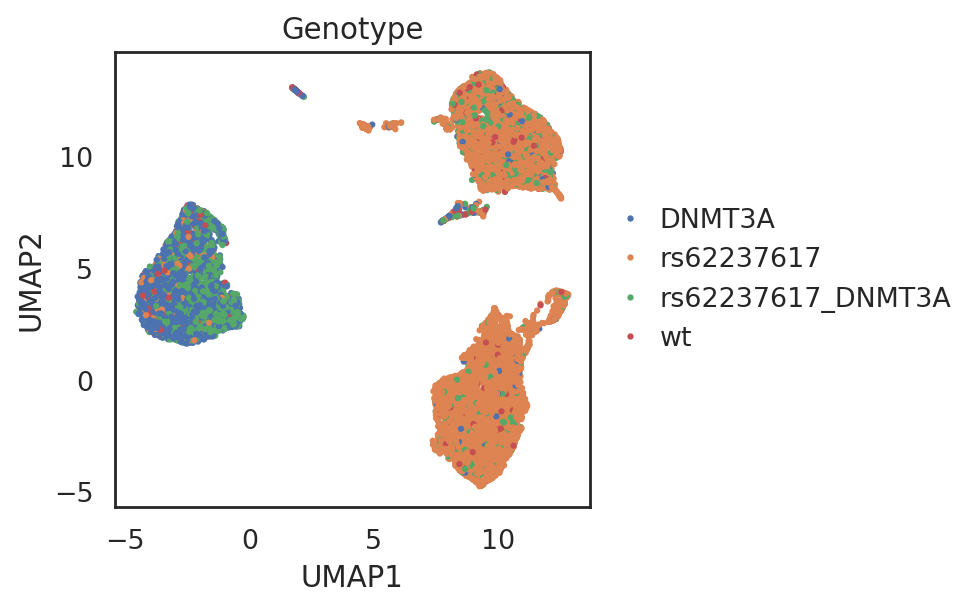

In [47]:
si.pl.umap(adata_C,
           color=['Genotype'],
           fig_size=(6,4),
           drawing_order='random')

In [48]:
#si.pl.umap??

## Visualize cell types and genes

In [49]:
adata_all_CG = si.tl.embed(adata_ref=adata_C,
                           list_adata_query=[adata_G])

Performing softmax transformation for query data 0;


In [50]:
## add annotations of all entities
adata_all_CG.obs['entity_anno'] = ""
adata_all_CG.obs.loc[adata_C.obs_names, 'entity_anno'] = adata_all_CG.obs.loc[adata_C.obs_names, 'clone_line'].tolist()
adata_all_CG.obs.loc[adata_C.obs_names, 'entity_anno'] = adata_all_CG.obs.loc[adata_C.obs_names, 'Genotype'].tolist()
adata_all_CG.obs.loc[adata_C.obs_names, 'entity_anno'] = adata_all_CG.obs.loc[adata_C.obs_names, 'celltype'].tolist()

adata_all_CG.obs.loc[adata_G.obs_names, 'entity_anno'] = 'gene'

adata_all_CG.obs.head()

,celltype,clone_line,Genotype,id_dataset,entity_anno
MCO_01329_ACAACAGAGAGGCTAA-1,PolyPlo MK,rs62237617_3,rs62237617,ref,PolyPlo MK
MCO_01329_GAACCAAAGGAAACTG-1,MK,rs62237617_3,rs62237617,ref,MK
MCO_01326_CAATGACTCACTTCAT-1,hESC,DNMT3A_3,DNMT3A,ref,hESC
MCO_01329_CGCCTCATCACCTGCT-1,PolyPlo MK,rs62237617_3,rs62237617,ref,PolyPlo MK
MCO_01328_CAGCATGTCGGTCAAT-1,early erythroid,rs62237617_3,rs62237617,ref,early erythroid


In [51]:
si.tl.umap(adata_all_CG,n_neighbors=15,n_components=2)


/group/soranzo/conda_envs/env_simba/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/group/soranzo/conda_envs/env_simba/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [52]:
#palette_entity_anno['gene'] = "#607e95"


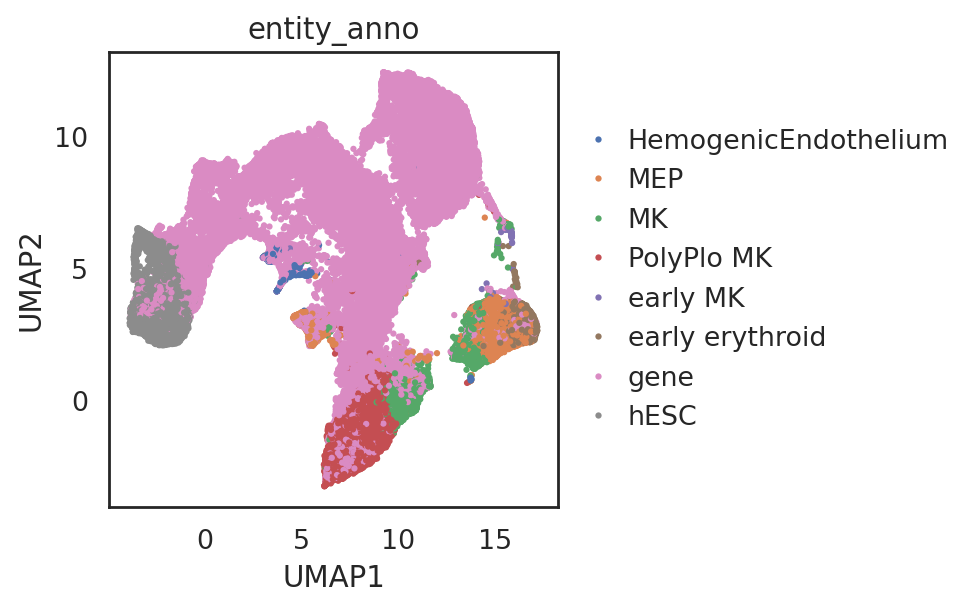

In [53]:
si.pl.umap(adata_all_CG,
           color=['entity_anno'],
           fig_size=(6,4),
           drawing_order='random')

## Add marker genes

In [54]:
marker_genes = ['SOX2','SOX4','POU5F1','KDR','CDH5', 'CD34','GYPA', 'HBA2', 'HBZ', 'ITGA2B', 'GP1BA','GP1BB', 'TUBB1', 'CDKN2D','MAPK14', 'PTPRC']


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


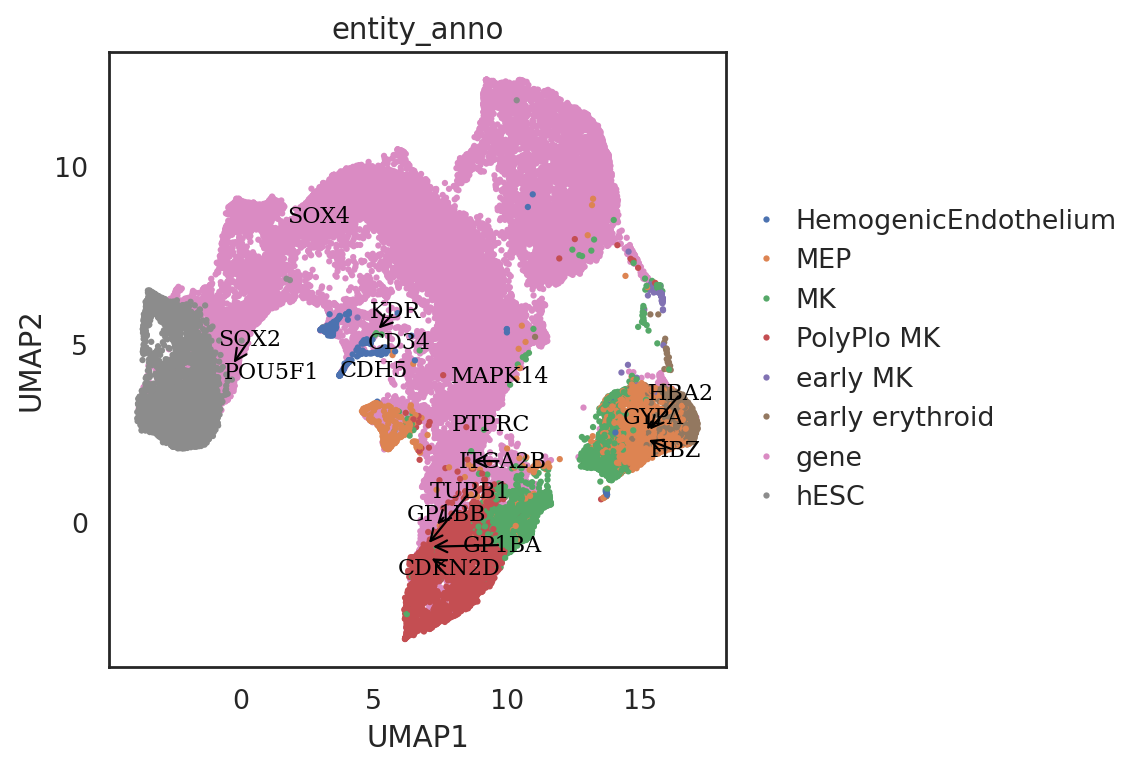

In [55]:
si.pl.umap(adata_all_CG[::-1,],
           color=['entity_anno'],          
           fig_size=(7,5),
           texts=marker_genes,
           text_expand=(2,1.5),
           show_texts=True,
           drawing_order='original')

## SIMBA metrics

### Genes

In [56]:
# genes
adata_cmp_CG = si.tl.compare_entities(adata_ref=adata_C,
                                      adata_query=adata_G)



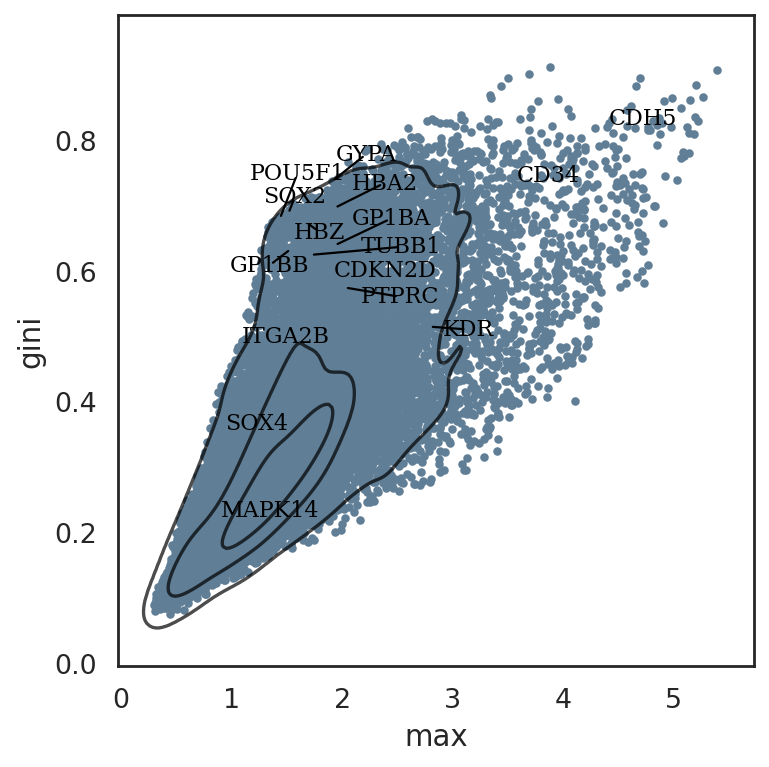

In [57]:
si.pl.entity_metrics(adata_cmp_CG,
                     x='max',
                     y='gini',
                     show_texts=True,
                     show_cutoff=False,
                     show_contour=True,
                     c='#607e95',
                     texts=marker_genes,
                     text_expand=(2,1.5))

In [58]:
genes_selected = adata_cmp_CG.var[(adata_cmp_CG.var['max']>2) & (adata_cmp_CG.var['gini']>0.4)].index.tolist()
len(genes_selected)

4153

### Motifs

In [59]:
# motifs
adata_cmp_CM = si.tl.compare_entities(adata_ref=adata_C,
                                      adata_query=adata_M)

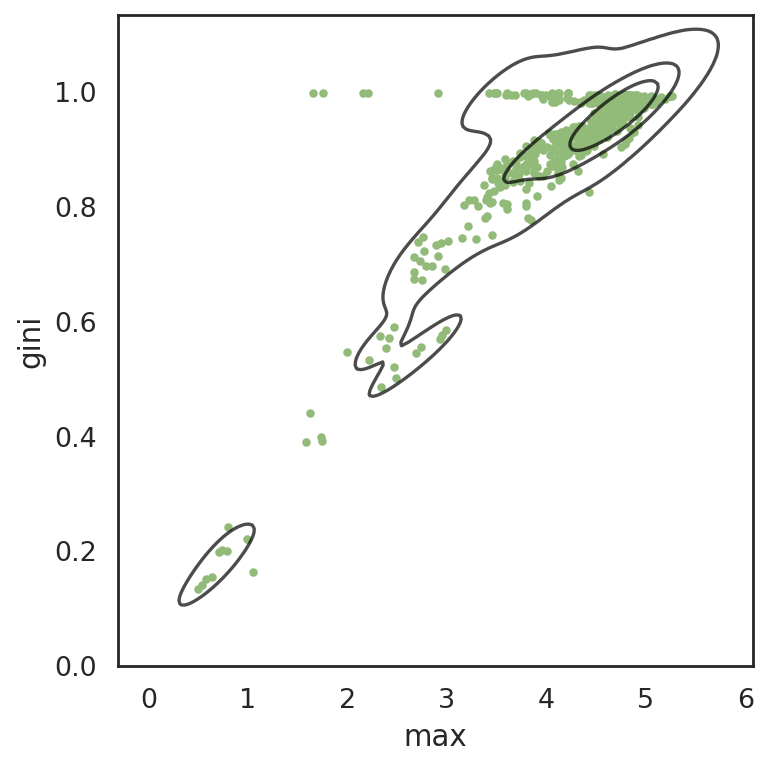

In [60]:
si.pl.entity_metrics(adata_cmp_CM,
                     x='max',
                     y='gini',
                     show_texts=False,
                     show_cutoff=False,
                     show_contour=True,
                     c='#92ba79',                    
                     text_expand=(2,1.5))

In [61]:
motifs_selected = adata_cmp_CM.var[(adata_cmp_CM.var['max']>3) & (adata_cmp_CM.var['gini']>0.7)].index.tolist()
len(motifs_selected)

586

### Peaks

In [ ]:
# peaks
adata_cmp_CP = si.tl.compare_entities(adata_ref=adata_C,
                                      adata_query=adata_P)

In [ ]:
si.pl.entity_metrics(adata_cmp_CP,
                     x='max',
                     y='gini',
                     show_texts=False,
                     show_cutoff=False,
                     show_contour=False,                     
                     text_expand=(2,1.5),
                     c='#e5c2c8')



## visualize embeddings of all entities including cells, genes, motifs, kmers, and peaks

In [ ]:
adata_all = si.tl.embed(adata_ref=adata_C,
                        list_adata_query=[adata_G, adata_M, adata_K, adata_P])

Performing softmax transformation for query data 0;
Performing softmax transformation for query data 1;
Performing softmax transformation for query data 2;
Performing softmax transformation for query data 3;


In [ ]:
adata_all.obs['entity_anno'] = ""
adata_all.obs.loc[adata_C.obs_names, 'entity_anno'] = adata_all.obs.loc[adata_C.obs_names, 'clone_line'].tolist()
adata_all.obs.loc[adata_C.obs_names, 'entity_anno'] = adata_all.obs.loc[adata_C.obs_names, 'Genotype'].tolist()
adata_all.obs.loc[adata_C.obs_names, 'entity_anno'] = adata_all.obs.loc[adata_C.obs_names, 'celltype'].tolist()

adata_all.obs.loc[adata_G.obs_names, 'entity_anno'] = 'gene'

adata_all.obs.head()

### Save object with selected features

In [ ]:
adata_all_selected = adata_all[adata_C.obs_names.to_list()
                               + genes_selected
                               + motifs_selected, ].copy()

# Save all results

In [1]:
workdir = '/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/Downstream_analysis_cluster_after_genotyping/result_SIMBA'

In [2]:
workdir

'/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/Downstream_analysis_cluster_after_genotyping/result_SIMBA'

In [3]:
adata_CG.write(os.path.join(workdir,'adata_CG.h5ad'))
adata_CP.write(os.path.join(workdir,'adata_CP.h5ad'))
adata_PM.write(os.path.join(workdir,'adata_PM.h5ad'))
adata_PK.write(os.path.join(workdir,'adata_PK.h5ad'))

adata_C.write(os.path.join(workdir,'adata_C.h5ad'))
adata_G.write(os.path.join(workdir,'adata_G.h5ad'))
adata_P.write(os.path.join(workdir,'adata_P.h5ad'))
adata_K.write(os.path.join(workdir,'adata_K.h5ad'))
adata_M.write(os.path.join(workdir,'adata_M.h5ad'))

adata_all.write(os.path.join(workdir,'adata_all.h5ad'))
adata_all_selected.write(os.path.join(workdir,'adata_all_selected.h5ad'))

adata_cmp_CG.write(os.path.join(workdir,'adata_cmp_CG.h5ad'))
adata_cmp_CM.write(os.path.join(workdir,'adata_cmp_CM.h5ad'))
adata_cmp_CP.write(os.path.join(workdir,'adata_cmp_CP.h5ad'))

NameError: name 'adata_CG' is not defined